x =  2.50 Å   E_elec =   -18.275781 kJ/mol   E_LJ =   200.065945 kJ/mol   E_total =   181.790164 kJ/mol
x =  2.75 Å   E_elec =   -24.577305 kJ/mol   E_LJ =    31.904149 kJ/mol   E_total =     7.326844 kJ/mol
x =  3.00 Å   E_elec =   -23.007247 kJ/mol   E_LJ =     5.138116 kJ/mol   E_total =   -17.869131 kJ/mol
x =  3.25 Å   E_elec =   -19.528215 kJ/mol   E_LJ =     0.157212 kJ/mol   E_total =   -19.371003 kJ/mol
x =  3.50 Å   E_elec =   -16.073500 kJ/mol   E_LJ =    -0.695762 kJ/mol   E_total =   -16.769262 kJ/mol
x =  3.75 Å   E_elec =   -13.159901 kJ/mol   E_LJ =    -0.699670 kJ/mol   E_total =   -13.859570 kJ/mol
x =  4.00 Å   E_elec =   -10.834545 kJ/mol   E_LJ =    -0.553983 kJ/mol   E_total =   -11.388527 kJ/mol
x =  4.25 Å   E_elec =    -9.005492 kJ/mol   E_LJ =    -0.412441 kJ/mol   E_total =    -9.417933 kJ/mol
x =  4.50 Å   E_elec =    -7.562064 kJ/mol   E_LJ =    -0.302293 kJ/mol   E_total =    -7.864357 kJ/mol
x =  4.75 Å   E_elec =    -6.411491 kJ/mol   E_LJ =    -0.221721

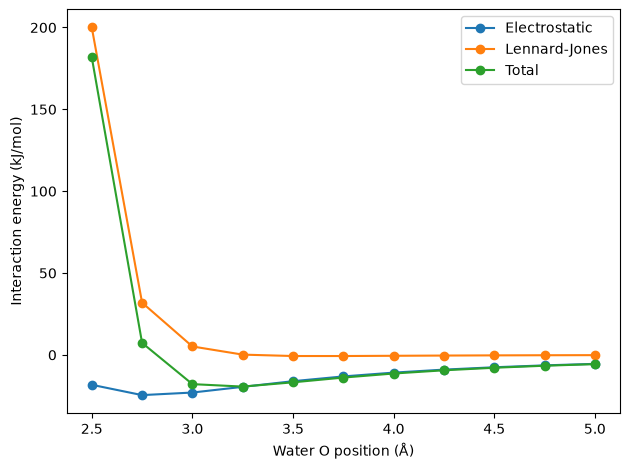

In [1]:
import numpy as np

from pyscf import gto, scf, qmmm


# ============================================================
# Constants
# ============================================================

HARTREE_TO_KJMOL = 2625.49962


# ============================================================
# Lennard-Jones energy
# ============================================================

def lj_energy(
    qm_coords,
    qm_atom_types,
    mm_coords,
    mm_atom_types,
    lj_params
):
    """
    QM-MM Lennard-Jones energy.

    Coordinates: Angstrom
    sigma:       Angstrom
    epsilon:     kJ/mol

    Lorentz-Berthelot mixing rules:
        sigma_ij   = (sigma_i + sigma_j) / 2
        epsilon_ij = sqrt(epsilon_i * epsilon_j)
    """

    total = 0.0

    for i, r_qm in enumerate(qm_coords):

        for j, r_mm in enumerate(mm_coords):

            qm_type = qm_atom_types[i]
            mm_type = mm_atom_types[j]

            r = np.linalg.norm(r_qm - r_mm)

            if r == 0.0:
                raise ValueError(
                    f"Zero distance between QM atom {i} "
                    f"and MM atom {j}"
                )

            sigma_qm = lj_params[qm_type]["sigma_A"]
            epsilon_qm = lj_params[qm_type]["epsilon_kJmol"]

            sigma_mm = lj_params[mm_type]["sigma_A"]
            epsilon_mm = lj_params[mm_type]["epsilon_kJmol"]

            sigma = 0.5 * (sigma_qm + sigma_mm)
            epsilon = np.sqrt(epsilon_qm * epsilon_mm)

            sr6 = (sigma / r) ** 6
            sr12 = sr6 ** 2

            total += 4.0 * epsilon * (sr12 - sr6)

    return total


# ============================================================
# Build TIP4P-D water
# ============================================================

def build_tip4p_d_water(x):

    # Oxygen position
    water_O = np.array([
        x,
        0.0,
        0.0
    ])

    # TIP4P geometry used in our previous test
    water_H1 = water_O + np.array([
         0.757,
         0.586,
         0.000
    ])

    water_H2 = water_O + np.array([
        -0.757,
         0.586,
         0.000
    ])

    water_M = water_O + np.array([
         0.000,
         0.151,
         0.000
    ])

    return water_O, water_H1, water_H2, water_M


# ============================================================
# 1. QM SYSTEM: OH-
# ============================================================

mol = gto.M(
    atom='''
        O    0.000    0.000    0.000
        H    0.970    0.000    0.000
    ''',
    basis='sto-3g',
    charge=-1,
    spin=0,
    unit='Angstrom',
    verbose=0
)


# ============================================================
# 2. LJ PARAMETERS
# ============================================================

lj_params = {

    "OH_O": {
        "sigma_A": 3.400,
        "epsilon_kJmol": 0.2508914038369354
    },

    "OH_H": {
        "sigma_A": 1.443,
        "epsilon_kJmol": 0.18390926154006562
    },

    # TEST TIP4P-D oxygen parameters
    "TIP4P_O": {
        "sigma_A": 3.15365,
        "epsilon_kJmol": 0.650194
    }
}


qm_coords = mol.atom_coords(unit='Angstrom')

qm_atom_types = [
    "OH_O",
    "OH_H"
]


# ============================================================
# 3. BARE QM ENERGY
#
# This does not change during the scan.
# ============================================================

mf_qm = scf.RHF(mol)

energy_qm_hartree = mf_qm.kernel()

energy_qm_kjmol = (
    energy_qm_hartree * HARTREE_TO_KJMOL
)


# ============================================================
# 4. DISTANCES TO SCAN
# ============================================================

distances = np.arange(
    2.5,
    5.01,
    0.25
)


# ============================================================
# 5. Storage
# ============================================================

results = []


# ============================================================
# 6. SCAN
# ============================================================

for x in distances:

    # --------------------------------------------------------
    # Build water
    # --------------------------------------------------------

    water_O, water_H1, water_H2, water_M = (
        build_tip4p_d_water(x)
    )

    # --------------------------------------------------------
    # TIP4P electrostatic sites
    # --------------------------------------------------------

    mm_charge_coords = np.array([
        water_H1,
        water_H2,
        water_M
    ])

    mm_charges = np.array([
        +0.58,
        +0.58,
        -1.16
    ])

    # --------------------------------------------------------
    # TIP4P LJ site
    #
    # Only oxygen has LJ.
    # --------------------------------------------------------

    mm_lj_coords = np.array([
        water_O
    ])

    mm_lj_types = [
        "TIP4P_O"
    ]

    # --------------------------------------------------------
    # QM/MM electrostatic calculation
    # --------------------------------------------------------

    mf_qmmm = qmmm.mm_charge(
        scf.RHF(mol),
        mm_charge_coords,
        mm_charges,
        unit='Angstrom'
    )

    energy_qmmm_hartree = mf_qmmm.kernel()

    energy_qmmm_kjmol = (
        energy_qmmm_hartree * HARTREE_TO_KJMOL
    )

    # --------------------------------------------------------
    # Electrostatic interaction
    # --------------------------------------------------------

    energy_electrostatic = (
        energy_qmmm_kjmol
        - energy_qm_kjmol
    )

    # --------------------------------------------------------
    # LJ interaction
    # --------------------------------------------------------

    energy_lj = lj_energy(
        qm_coords,
        qm_atom_types,
        mm_lj_coords,
        mm_lj_types,
        lj_params
    )

    # --------------------------------------------------------
    # Total interaction
    # --------------------------------------------------------

    energy_total = (
        energy_electrostatic
        + energy_lj
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results.append([
        x,
        energy_electrostatic,
        energy_lj,
        energy_total
    ])

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"x = {x:5.2f} Å   "
        f"E_elec = {energy_electrostatic:12.6f} kJ/mol   "
        f"E_LJ = {energy_lj:12.6f} kJ/mol   "
        f"E_total = {energy_total:12.6f} kJ/mol"
    )


# ============================================================
# 7. Convert to numpy array
# ============================================================

results = np.array(results)


# ============================================================
# 8. Optional: plot
# ============================================================

import matplotlib.pyplot as plt

x = results[:, 0]
e_elec = results[:, 1]
e_lj = results[:, 2]
e_total = results[:, 3]

plt.figure()

plt.plot(
    x,
    e_elec,
    marker='o',
    label='Electrostatic'
)

plt.plot(
    x,
    e_lj,
    marker='o',
    label='Lennard-Jones'
)

plt.plot(
    x,
    e_total,
    marker='o',
    label='Total'
)

plt.xlabel("Water O position (Å)")
plt.ylabel("Interaction energy (kJ/mol)")
plt.legend()
plt.tight_layout()
plt.show()